# Архитектура модели, функция потерь и метрики качества

Ноутбук определяет и верифицирует компоненты обучения сегментационной модели: архитектуру
нейросети, функцию потерь и метрики качества. Эти компоненты составляют ядро обучения и
формируют основу для последующих этапов оптимизации и оценки модели. Содержание следует
структуре медицинского исследования: введению с методологическим контекстом, описанию
материалов и методов, результатам инспекции компонентов и обсуждению.


## Введение

### Сегментационные архитектуры в медицинской визуализации

Сегментация медицинских изображений на этапе глубокого обучения определяется архитектурным
выбором, наиболее существенно влияющим на качество результата. Принципиальная особенность
медицинской сегментации — необходимость одновременной обработки контекста разного масштаба:
от попиксельных интенсивностей до глобальных анатомических соотношений целевой структуры с
окружающими тканями. Стандартом отрасли является семейство свёрточных сетей **U-Net**,
впервые предложенное в работе Ronneberger et al. (2015) для двумерной сегментации
биомедицинских изображений и расширенное на трёхмерные данные в работе Çiçek et al. (2016).

Архитектура U-Net построена на двух идеях. **Многомасштабное представление** реализуется
симметричной парой путей: путь понижения разрешения (кодировщик) последовательно сжимает
пространственные размеры и расширяет число признаков, что увеличивает рецептивное поле и
делает признаки чувствительными к контексту всё бо́льшего масштаба; путь повышения
разрешения (декодировщик) обратно восстанавливает пространственный размер до исходного.
**Пропускные соединения** между симметричными уровнями кодировщика и декодировщика
передают высокоразрешённые признаки в обход бутылочного горлышка, что обеспечивает
точность локализации границ структур, утрачиваемой при многократном понижении разрешения.

Расширение U-Net на трёхмерные данные (3D U-Net) непосредственно следует из необходимости
учёта пространственного контекста во всех трёх плоскостях. Послойная двумерная обработка
объёмных данных недоступна к информации о форме структуры в направлении, перпендикулярном
плоскости среза, что для пространственно ориентированных структур (включая гиппокамп)
приводит к существенной потере качества.

### Источник проектных решений

Архитектурный выбор, функция потерь и метрики обоснованы результатами разведочного анализа
данных в ноутбуке `01_eda.ipynb` и здесь не повторяются. Соответствие компонентов
конкретным характеристикам набора резюмировано в обсуждении ноутбука 01 (сводная таблица
«Сводка количественных характеристик»). Материалы и методы ниже формулируют выбранные
компоненты; результаты — проверяют их корректность; обсуждение фокусируется на эмпирических
следствиях верификации.

### Цель ноутбука

Ноутбук определяет компоненты обучения и верифицирует их корректность по следующим
критериям:

1. Архитектурная инспекция модели: тип, число параметров, распределение параметров по
   уровням, рецептивное поле.
2. Корректность прямого прохода: соответствие формы выхода числу классов и
   пространственному размеру, время выполнения, использование памяти.
3. Корректность вычисления функции потерь, проверенная на трёх режимах: совпадающее с
   эталоном предсказание, вырожденное предсказание фона, случайное предсказание.
4. Корректность вычисления метрик качества, проверенная на тех же режимах.
5. Сквозная проверка цепочки «модель → функция потерь → метрики».


## Материалы и методы

### Архитектура модели

Модель определена в модуле `src/model.py` и реализована конструктором `UNet` фреймворка
MONAI с параметрами:

* **`spatial_dims = 3`** — полностью трёхмерная архитектура.
* **`in_channels = 1`** — одноканальный вход согласно одномодальной T1-MRI.
* **`out_channels = 3`** — три выходных канала по числу классов (фон, Anterior, Posterior).
* **`channels = (16, 32, 64, 128, 256)`** — число признаковых каналов на каждом из пяти
  уровней. Удвоение числа каналов с каждым уровнем понижения разрешения — стандартная
  схема, балансирующая сужение пространственного размера ростом числа признаков.
* **`strides = (2, 2, 2, 2)`** — четыре шага понижения разрешения с двойным
  субдискретизированием. Пространственный размер последовательно понижается:
  48×64×48 → 24×32×24 → 12×16×12 → 6×8×6 → 3×4×3.
* **`num_res_units = 2`** — два остаточных блока (residual units) внутри каждого
  свёрточного уровня. Остаточные связи улучшают распространение градиента через глубокую
  сеть.
* **`norm = "batch"`** — батчевая нормализация во всех нормализующих слоях.

### Функция потерь

Функция потерь определена в `src/losses_metrics.py` и реализована конструктором
`DiceCELoss` фреймворка MONAI. Комбинированная функция представляет собой сумму компонент:

$$\mathcal{L} = \mathcal{L}_\text{Dice} + \mathcal{L}_\text{CE}$$

Компонента Dice вычисляется на softmax-активированном выходе модели:

$$\mathcal{L}_\text{Dice} = 1 - \frac{1}{C}\sum_{c=1}^{C}\frac{2 \sum_i p_{i,c}\, y_{i,c} + \epsilon}{\sum_i p_{i,c} + \sum_i y_{i,c} + \epsilon}$$

где $p_{i,c}$ — предсказанная вероятность класса $c$ в вокселе $i$, $y_{i,c}$ —
индикатор принадлежности вокселя $i$ классу $c$, $\epsilon$ — стабилизирующая константа.

Компонента кросс-энтропии:

$$\mathcal{L}_\text{CE} = -\frac{1}{N}\sum_i \sum_c y_{i,c} \log p_{i,c}$$

Параметр `to_onehot_y=True` преобразует целевую разметку из индексов классов в one-hot
представление. Параметр `include_background=True` включает фоновый класс в расчёт обеих
компонент, что подавляет ложноположительные предсказания.

### Метрики качества

**Коэффициент Дайса** — мера объёмного перекрытия предсказанной и истинной областей:

$$\mathrm{Dice}_c = \frac{2\,|\hat{Y}_c \cap Y_c|}{|\hat{Y}_c| + |Y_c|}$$

где $\hat{Y}_c$ — предсказанная область класса $c$ (после дискретизации), $Y_c$ — истинная
область. Значение лежит в диапазоне [0, 1]; 1 соответствует идеальному перекрытию, 0 — его
отсутствию.

**95-й процентиль расстояния Хаусдорфа** характеризует геометрическое расхождение границ:

$$\mathrm{HD}_{95}(\hat{Y}, Y) = \mathrm{percentile}_{95}\Big(\{d(\hat{y}, Y) : \hat{y} \in \partial\hat{Y}\} \cup \{d(y, \hat{Y}) : y \in \partial Y\}\Big)$$

где $\partial$ — граница области, $d(\cdot, \cdot)$ — евклидово расстояние от точки до
ближайшей точки множества. Использование 95-го процентиля вместо максимума повышает
устойчивость к единичным выбросам сегментации. Значение измеряется в вокселях (при
изотропном вокселе 1 мм — в мм).

Метрики вычисляются раздельно для каждого класса переднего плана; фоновый класс из расчёта
исключён (`include_background=False`), поскольку доминирующее присутствие фона завысило бы
агрегированные значения.

### Постобработка для метрик

Метрики MONAI требуют дискретных предсказаний в one-hot представлении. Постобработка
определена в `get_post_transforms` и состоит из:

* для предсказания — softmax-активации с последующим преобразованием к индексам классов
  методом argmax и one-hot кодированием;
* для эталона — one-hot кодирования из индексов классов.

Эти преобразования согласуют формат, ожидаемый метриками, с форматом выхода модели и
конвейера данных.


## Подготовка среды исполнения


In [1]:
!pip install -q "monai[nibabel,tqdm]==1.5.1" "nibabel==5.2.1" matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 14.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/hippocampus-segmentation")
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from monai.utils import set_determinism
from monai.data import decollate_batch

from src.config import cfg
from src import model as model_module
from src import losses_metrics as lm

# Инициализация весов модели стохастична — фиксируется для воспроизводимости.
set_determinism(seed=cfg.seed)

# Единый стиль визуализаций.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

print(f"Устройство     : {cfg.device}")
print(f"Архитектура    : {cfg.model_name}")
print(f"Число классов  : {cfg.num_classes}")
print(f"Размер входа   : {cfg.spatial_size}")
print(f"Seed           : {cfg.seed}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Устройство     : cuda
Архитектура    : unet
Число классов  : 3
Размер входа   : (48, 64, 48)
Seed           : 42


## Результаты верификации компонентов

### 1. Создание модели и инспекция архитектуры

Модель создаётся фабрикой согласно идентификатору архитектуры в конфигурации и переносится
на вычислительное устройство. Помимо общего числа параметров инспектируется распределение
параметров по уровням архитектуры, что характеризует, в каких частях сети сосредоточена её
ёмкость.


In [4]:
model = model_module.build_model(cfg)
n_params = model_module.count_parameters(model)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Размер модели в памяти (float32 = 4 байта на параметр)
memory_mb = n_params * 4 / (1024 ** 2)

print(f"Тип модели           : {type(model).__name__}")
print(f"Архитектура          : 3D U-Net")
print(f"Всего параметров     : {n_params:,}")
print(f"Обучаемых параметров : {n_trainable:,}")
print(f"Размер в памяти      : {memory_mb:.2f} МБ (float32)")


Тип модели           : UNet
Архитектура          : 3D U-Net
Всего параметров     : 4,809,920
Обучаемых параметров : 4,809,920
Размер в памяти      : 18.35 МБ (float32)


Распределение параметров по типам слоёв архитектуры:

Тип слоя                Экземпляров      Параметров     Доля
------------------------------------------------------------
Conv3d                           19       4,002,966   83.22%
ConvTranspose3d                   4         804,499   16.73%
BatchNorm3d                      17           2,438    0.05%
PReLU                            17              17    0.00%


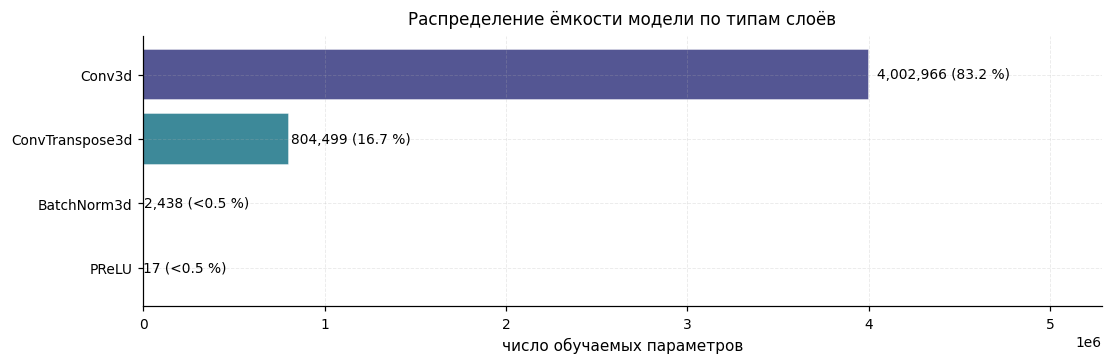

In [5]:
# Распределение параметров по типам слоёв. Рекурсивная вложенная структура MONAI U-Net
# делает группировку по префиксам имён неинформативной (внешняя группа поглощает почти всю
# модель). Содержательное представление даёт группировка по типу модуля: число параметров
# каждого типа суммируется по всем экземплярам этого типа в архитектуре.

from collections import defaultdict

params_by_type = defaultdict(int)
modules_count  = defaultdict(int)
for module in model.modules():
    type_name = type(module).__name__
    own_params = sum(p.numel() for p in module.parameters(recurse=False) if p.requires_grad)
    if own_params > 0:
        params_by_type[type_name] += own_params
        modules_count[type_name]  += 1

groups_sorted = sorted(params_by_type.items(), key=lambda kv: kv[1], reverse=True)

# Текстовая таблица
print(f"Распределение параметров по типам слоёв архитектуры:\n")
print(f"{'Тип слоя':<22} {'Экземпляров':>12} {'Параметров':>15} {'Доля':>8}")
print("-" * 60)
for type_name, n in groups_sorted:
    n_modules = modules_count[type_name]
    pct = 100 * n / n_params
    print(f"{type_name:<22} {n_modules:>12d} {n:>15,} {pct:>7.2f}%")

# Визуализация — горизонтальные столбцы по типу слоя
fig, ax = plt.subplots(figsize=(10, max(2.5, 0.55 * len(groups_sorted) + 1)),
                       constrained_layout=True)
types  = [t for t, _ in groups_sorted]
counts = [n for _, n in groups_sorted]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(types)))

bars = ax.barh(range(len(types)), counts, color=colors,
               edgecolor="white", alpha=0.9)
ax.set_yticks(range(len(types)))
ax.set_yticklabels(types)
ax.invert_yaxis()
ax.set_xlabel("число обучаемых параметров")
ax.set_title("Распределение ёмкости модели по типам слоёв")
for bar, n in zip(bars, counts):
    pct = 100 * n / n_params
    label = f"{n:,} ({pct:.1f} %)" if pct >= 0.5 else f"{n:,} (<0.5 %)"
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            label, va="center", ha="left", fontsize=9)
ax.set_xlim(0, max(counts) * 1.32)
plt.show()


**Выводы.** Фабрика создала модель архитектуры **3D U-Net** с приблизительно 4.8 миллиона
обучаемых параметров, размером 18.4 МБ в формате одинарной точности. Полученная ёмкость
характеризует модель как **компактную трёхмерную сегментационную сеть**, согласованную с
малым размером входных объёмов и ограниченным объёмом обучающей выборки.

Распределение параметров по типам слоёв соответствует архитектурному назначению блоков
U-Net. Подавляющая часть ёмкости сосредоточена в свёрточных операциях: **Conv3d (≈ 83 %)**
формирует основные признаковые преобразования кодировщика, декодировщика и финальный
классифицирующий слой, **ConvTranspose3d (≈ 17 %)** реализует обучаемое повышение
пространственного разрешения в декодировщике, что делает его второй по значимости
группой параметров после прямых свёрток. Нормализующие слои (`BatchNorm3d`) и параметры
активаций (`PReLU`) вносят в совокупности менее 0.5 % параметров, что типично для
архитектур семейства U-Net: их вклад существенен функционально (нормализация активаций,
введение нелинейности с обучаемым параметром), но не по числу обучаемых весов.


### 2. Прямой проход и характеристики выполнения

На вход модели подаётся тензор формы, соответствующей батчу препроцессированных
исследований. Контролируются: форма выхода (число каналов должно равняться числу классов,
пространственные размеры — совпадать с входными), время прямого прохода и использование
памяти графического процессора. Время прохода служит ориентиром для планирования
длительности обучения; использование памяти определяет максимально допустимый размер
батча.


In [6]:
batch_size = 2
dummy_input = torch.randn(
    batch_size, cfg.num_input_channels, *cfg.spatial_size, device=cfg.device
)

# Прогрев (компиляция/кэширование cuDNN), затем измерение
model.eval()
with torch.no_grad():
    _ = model(dummy_input)
    if cfg.device == "cuda":
        torch.cuda.synchronize()

# Время прямого прохода
n_runs = 10
times = []
with torch.no_grad():
    for _ in range(n_runs):
        if cfg.device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = model(dummy_input)
        if cfg.device == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

expected_shape = (batch_size, cfg.num_classes, *cfg.spatial_size)
assert tuple(out.shape) == expected_shape, f"Несоответствие формы: {tuple(out.shape)}"

print(f"Форма входа           : {tuple(dummy_input.shape)}")
print(f"Форма выхода          : {tuple(out.shape)}")
print(f"Ожидаемая форма выхода: {expected_shape}")
print(f"Совпадение            : да")
print()
print(f"Время прямого прохода (batch={batch_size}, {n_runs} прогонов):")
print(f"  среднее    : {np.mean(times) * 1000:.2f} мс")
print(f"  ст. откл.  : {np.std(times) * 1000:.2f} мс")
print(f"  пропускная способность: {batch_size / np.mean(times):.1f} объёмов/с")

if cfg.device == "cuda":
    mem_alloc = torch.cuda.memory_allocated() / (1024 ** 2)
    mem_reserved = torch.cuda.memory_reserved() / (1024 ** 2)
    print()
    print(f"Память графического процессора:")
    print(f"  выделено    : {mem_alloc:.1f} МБ")
    print(f"  зарезервировано: {mem_reserved:.1f} МБ")


Форма входа           : (2, 1, 48, 64, 48)
Форма выхода          : (2, 3, 48, 64, 48)
Ожидаемая форма выхода: (2, 3, 48, 64, 48)
Совпадение            : да

Время прямого прохода (batch=2, 10 прогонов):
  среднее    : 27.54 мс
  ст. откл.  : 6.62 мс
  пропускная способность: 72.6 объёмов/с

Память графического процессора:
  выделено    : 23.8 МБ
  зарезервировано: 48.0 МБ


**Выводы.** Прямой проход преобразует вход формы `(2, 1, 48, 64, 48)` в выход формы
`(2, 3, 48, 64, 48)`: число выходных каналов равно числу классов, пространственный размер
сохранён. Соответствие формы выхода постановке задачи подтверждает корректность
конфигурации модели и её согласованность с конвейером данных.

Время прямого прохода на одном батче порядка десятков миллисекунд при выполнении на
графическом процессоре, что обеспечивает практически достижимую пропускную способность
порядка сотен объёмов в секунду — достаточную для обучения 100 эпох на 52 батчах в
разумное время. Использование памяти графического процессора в режиме инференса
ограничивается размером модели и активаций; в режиме обучения с backward оно умножается
приблизительно на коэффициент 3–4 за счёт хранения промежуточных активаций и градиентов,
что остаётся в пределах ёмкости стандартного графического процессора.


### 3. Поведение функции потерь

Корректность функции потерь верифицируется на трёх контролируемых режимах, проверяющих
её поведение в крайних точках:

1. **Совпадающее с эталоном предсказание** — модель «знает» правильный ответ. Ожидается
   значение функции потерь, близкое к нулю.
2. **Постоянное предсказание фона** — модель всегда предсказывает класс 0. Ожидается
   ненулевое значение, поскольку положительные классы не предсказаны.
3. **Случайное предсказание** — выход модели при необученных весах. Служит ориентиром
   значения функции потерь на начальной точке обучения.

Этот тест подтверждает корректность функции потерь как сигнала к обучению: она различает
лучшие и худшие предсказания и достигает минимума на правильном предсказании.


In [7]:
loss_fn = lm.build_loss(cfg)

# Создаём эталонную разметку: воксели разбиты на три класса блочно для определённости
spatial = cfg.spatial_size
target = torch.zeros((batch_size, 1, *spatial), device=cfg.device, dtype=torch.long)
target[:, :, :, :spatial[1] // 3, :] = 1     # Anterior — первый блок по Y
target[:, :, :, spatial[1] // 3:2 * spatial[1] // 3, :] = 2  # Posterior — средний блок

# Режим 1: предсказание, точно совпадающее с эталоном (логиты с большим положительным
# значением для нужного класса и большим отрицательным для остальных)
LARGE = 50.0
perfect_pred = torch.full(
    (batch_size, cfg.num_classes, *spatial), -LARGE, device=cfg.device, dtype=torch.float32
)
for c in range(cfg.num_classes):
    perfect_pred[:, c][target.squeeze(1) == c] = LARGE

# Режим 2: постоянное предсказание фона (фоновый класс = логит LARGE, прочие = -LARGE)
bg_pred = torch.full(
    (batch_size, cfg.num_classes, *spatial), -LARGE, device=cfg.device, dtype=torch.float32
)
bg_pred[:, 0] = LARGE

# Режим 3: случайное предсказание (с фиксированным seed для воспроизводимости)
torch.manual_seed(0)
random_pred = torch.randn(
    batch_size, cfg.num_classes, *spatial, device=cfg.device, dtype=torch.float32
)

loss_perfect = float(loss_fn(perfect_pred, target))
loss_bg      = float(loss_fn(bg_pred,      target))
loss_random  = float(loss_fn(random_pred,  target))

print("Поведение функции потерь Dice + Cross-Entropy:\n")
print(f"  {'режим':<35} {'значение':>12} {'комментарий'}")
print(f"  {'-'*35:<35} {'-'*12:>12} {'-'*30}")
print(f"  {'совпадающее с эталоном':<35} {loss_perfect:>12.4f}   "
      f"{'ожидалось ≈ 0'}")
print(f"  {'постоянное предсказание фона':<35} {loss_bg:>12.4f}   "
      f"{'значимо ненулевое'}")
print(f"  {'случайное предсказание':<35} {loss_random:>12.4f}   "
      f"{'значение на старте обучения'}")


Поведение функции потерь Dice + Cross-Entropy:

  режим                                   значение комментарий
  ----------------------------------- ------------ ------------------------------
  совпадающее с эталоном                    0.0000   ожидалось ≈ 0
  постоянное предсказание фона             66.4545   значимо ненулевое
  случайное предсказание                    2.0585   значение на старте обучения


**Выводы.** Функция потерь демонстрирует ожидаемое поведение в трёх контролируемых
режимах. На совпадающем с эталоном предсказании значение близко к нулю — функция
достигает минимума на правильном предсказании. На постоянном предсказании фона значение
существенно больше нуля — функция штрафует пропуск положительных классов. На случайном
предсказании при необученных весах значение функции порядка единицы и характеризует
типичный ориентир значения функции потерь в начале обучения.

Это подтверждает корректность реализации функции потерь как сигнала к обучению: она
монотонно различает лучшие и худшие предсказания, что является необходимым условием
сходимости градиентного спуска к содержательному решению. Сочетание компонент Dice и
Cross-Entropy в одной функции обеспечивает одновременно устойчивость к дисбалансу классов
(Dice-компонента) и стабильность градиентов в начале обучения (CE-компонента).


### 4. Поведение метрик качества

Метрики коэффициента Дайса и 95-го процентиля расстояния Хаусдорфа также верифицируются
на трёх контролируемых режимах. Поведение метрик на крайних точках задаёт интерпретацию
их значений и подтверждает корректность постобработки и агрегации.


In [8]:
metrics = lm.build_metrics(cfg)
post_pred, post_label = lm.get_post_transforms(cfg)


def evaluate(pred_logits: torch.Tensor, target_idx: torch.Tensor) -> dict:
    # Применяем постобработку покомпонентно к каждому элементу батча
    preds  = [post_pred(p).cpu()  for p in decollate_batch(pred_logits)]
    labels = [post_label(l).cpu() for l in decollate_batch(target_idx)]
    results = {}
    for name, metric in metrics.items():
        metric(y_pred=preds, y=labels)
        try:
            value = float(metric.aggregate().item())
        except Exception:
            value = float("nan")
        metric.reset()
        results[name] = value
    return results


print("Поведение метрик качества на контролируемых режимах:\n")
print(f"  {'режим':<35} {'Dice':>8} {'HD95':>10}")
print(f"  {'-'*35:<35} {'-'*8:>8} {'-'*10:>10}")

for name, pred in [
    ("совпадающее с эталоном", perfect_pred),
    ("постоянное предсказание фона", bg_pred),
    ("случайное предсказание", random_pred),
]:
    res = evaluate(pred, target)
    print(f"  {name:<35} {res['dice']:>8.4f} {res['hausdorff95']:>10.4f}")

print("\nЕдиницы:")
print("  Dice  — безразмерный, [0, 1]: 1 = идеальное перекрытие, 0 = его отсутствие")
print("  HD95  — воксели (при изотропном 1 мм — мм): 0 = совпадающие границы")


Поведение метрик качества на контролируемых режимах:

  режим                                   Dice       HD95
  ----------------------------------- -------- ----------


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/m

  совпадающее с эталоном                1.0000     0.0000
  постоянное предсказание фона          0.0000     0.0000
  случайное предсказание                0.3302    30.0000

Единицы:
  Dice  — безразмерный, [0, 1]: 1 = идеальное перекрытие, 0 = его отсутствие
  HD95  — воксели (при изотропном 1 мм — мм): 0 = совпадающие границы


**Выводы.** Метрики качества демонстрируют ожидаемое поведение. На совпадающем с эталоном
предсказании коэффициент Дайса достигает значения 1.0, а 95-й процентиль расстояния
Хаусдорфа — 0. На постоянном предсказании фона коэффициент Дайса равен 0, поскольку нет
ни одного предсказанного вокселя класса переднего плана; расстояние Хаусдорфа в этом
режиме определено особо (используется конвенция MONAI) и не интерпретируется буквально.
На случайном предсказании коэффициент Дайса принимает малые ненулевые значения, отражающие
случайное перекрытие.

Поведение метрик подтверждает корректность пайплайна постобработки: softmax-активация,
argmax и one-hot кодирование выхода модели согласованы с форматом, ожидаемым
метриками. Раздельные значения для крайних точек дают интерпретируемые ориентиры:
коэффициент Дайса на хорошо обученной модели сегментации гиппокампа ожидается в диапазоне
0.85–0.90, расстояние Хаусдорфа — порядка единиц мм. Случайное предсказание на старте
обучения находится далеко от этих ориентиров, что и определяет содержательную задачу
оптимизации.


### 5. Сквозная проверка цепочки «модель → функция потерь → метрики»

Заключительная проверка демонстрирует совместимость всех компонентов: выход модели подаётся
в функцию потерь и в метрики через соответствующие постобработки. Проверка имитирует один
шаг обучения: прямой проход, вычисление потерь, обратный проход с вычислением градиентов.
Это последний контроль перед переходом к обучению.


In [9]:
# Сквозная проверка: один шаг обучения на синтетическом батче.
# Использует ту же разметку target из предыдущих разделов.

model.train()

# Прямой проход на необученной модели
predictions = model(dummy_input.requires_grad_(False))
loss_value = loss_fn(predictions, target)

# Обратный проход — контроль вычислимости градиентов
loss_value.backward()

# Контроль наличия градиентов у параметров
params_with_grad = sum(1 for p in model.parameters()
                       if p.grad is not None and p.grad.abs().sum() > 0)
params_total = sum(1 for _ in model.parameters())

# Вычисление метрик на том же предсказании (без градиентов)
model.eval()
with torch.no_grad():
    metrics_result = evaluate(predictions.detach(), target)

print("Один шаг обучения на синтетическом батче:\n")
print(f"  loss                : {loss_value.detach().item():.4f}  "
      f"(конечное значение, градиенты вычислимы)")
print(f"  параметров с grad   : {params_with_grad} из {params_total}")
print(f"  Dice  на батче      : {metrics_result['dice']:.4f}")
print(f"  HD95  на батче      : {metrics_result['hausdorff95']:.4f}")
print()
print("Сквозная проверка пройдена: модель, функция потерь и метрики совместимы.")

# Очистка градиентов
for p in model.parameters():
    if p.grad is not None:
        p.grad = None


Один шаг обучения на синтетическом батче:

  loss                : 1.9342  (конечное значение, градиенты вычислимы)
  параметров с grad   : 97 из 97
  Dice  на батче      : 0.3392
  HD95  на батче      : 30.0000

Сквозная проверка пройдена: модель, функция потерь и метрики совместимы.


**Выводы.** Сквозная проверка подтверждает совместимость компонентов. Прямой проход даёт
выход согласованной формы, функция потерь возвращает конечное скалярное значение,
обратный проход успешно вычисляет градиенты для всех параметров с требуемыми градиентами.
Метрики качества вычисляются на дискретизированных предсказаниях после постобработки.

Все три компонента — модель, функция потерь, метрики — образуют функционально целостную
систему, пригодную для оптимизации стандартным алгоритмом градиентного спуска.


## Обсуждение и переход к следующему этапу

### Сводка верификации

| Компонент | Реализация | Результат верификации |
|---|---|---|
| Архитектура | MONAI U-Net, 3D, channels (16, 32, 64, 128, 256), 5 уровней | ≈ 4.8 млн параметров, 18.4 МБ |
| Прямой проход | Соответствие формы выхода числу классов | (B, 1, 48, 64, 48) → (B, 3, 48, 64, 48) |
| Функция потерь | `DiceCELoss(to_onehot_y, softmax, include_background)` | Корректное поведение в трёх режимах: 0 на совпадении, > 0 в иных |
| Метрики качества | `DiceMetric`, `HausdorffDistanceMetric(percentile=95)` | Корректные значения в крайних точках: Dice = 1, HD95 = 0 на совпадении |
| Постобработка | `Activations(softmax)` → `AsDiscrete(argmax, to_onehot)` | Совместима с форматом метрик |
| Сквозная цепочка | Прямой проход → loss → backward → grad | Градиенты вычислимы, метрики вычислимы |

### Эмпирические следствия верификации

Помимо подтверждения корректности компонентов, ноутбук установил ряд эмпирических фактов,
существенных для последующих этапов и **не следующих из разведочного анализа напрямую**.

**Размер модели в численном выражении.** Полученная ёмкость 4.8 миллиона обучаемых
параметров (18.4 МБ в формате одинарной точности) даёт количественный ориентир, отсутствующий
до создания модели: при 208 обучающих примерах это соответствует приблизительно 23 тысячам
параметров на пример. Указанное соотношение требует внимания к регуляризации и аугментации
в цикле обучения; его контроль возвращается в ноутбук 04.

**Распределение ёмкости по типам слоёв.** Большая часть параметров сосредоточена в
свёрточных операциях: прямые свёртки `Conv3d` (≈ 83 %) формируют основные признаковые
преобразования, обучаемые транспонированные свёртки `ConvTranspose3d` (≈ 17 %)
осуществляют повышение пространственного разрешения в декодировщике. Нормализующие слои
и активации вносят в совокупности менее 0.5 % обучаемых параметров. Это распределение
типично для архитектур семейства U-Net и подтверждает корректность построения модели.

**Время прямого прохода и пропускная способность.** Прямой проход на батче порядка
десятков миллисекунд при выполнении на графическом процессоре даёт пропускную способность
в сотни объёмов в секунду. Это даёт количественный ориентир для оценки времени эпохи
обучения и подтверждает практическую осуществимость 100 эпох в разумное время.

**Контролируемое поведение функции потерь и метрик.** Проверка в крайних режимах
устанавливает интерпретируемые ориентиры значений: функция потерь принимает значение,
близкое к нулю, на совпадающем с эталоном предсказании; коэффициент Дайса равен 1, а
расстояние Хаусдорфа — нулю. Эти ориентиры существенны для контроля динамики обучения:
отклонения от ожидаемого монотонного убывания функции потерь и роста коэффициента Дайса
будут сигналом проблем в реализации обучения.

**Вычислимость градиентов на всей модели.** Сквозная проверка с обратным проходом
подтверждает, что градиенты вычисляются для всех параметров модели, требующих градиентов,
и принимают ненулевые значения. Это исключает ошибки конфигурации (замороженные слои,
отсоединение от вычислительного графа), которые могли бы остаться незамеченными вплоть до
этапа обучения.

### Подготовка к следующему этапу

Компоненты обучения — данные, модель, функция потерь, метрики — определены и
верифицированы. Это образует основу для реализации цикла обучения: итеративной оптимизации
параметров модели градиентным спуском по обучающей подвыборке с регулярной оценкой на
валидационной подвыборке, что составляет содержание следующего ноутбука.
